# ML Statistical Arbitrage (Offline Production Notebook)

This file uses real market data stored locally to allow for offline execution and reproducibility. It can be easily modified to work with live data.

We compare Ridge vs Random Forest models. Transactions costs are accounted for.

In [36]:
#import sys
#from pathlib import Path
#sys.path.append(str(Path().resolve().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [37]:
from src.data import load_prices, compute_returns
from src.features import create_features
from src.models import train_model
from src.walkforward import walk_forward
from src.backtest import backtest


In [38]:
from pathlib import Path

PROJECT_ROOT = Path().resolve()
while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

results_dir = PROJECT_ROOT / "results"
plots_dir = results_dir / "plots"

plots_dir.mkdir(parents=True, exist_ok=True)

In [39]:
prices = load_prices()
returns = compute_returns(prices)
features = create_features(returns)


In [40]:
target = returns['SPY'].shift(-1)
data = features.copy()
data['target'] = target
data = data.dropna()

X = data.drop(columns=['target'])
y = data['target']


In [41]:
# WARNING: Very time-consuming step

ridge_preds = walk_forward(X, y, lambda X,y: train_model(X,y,'ridge'), train_size=1000)
rf_preds = walk_forward(X, y, lambda X,y: train_model(X,y,'rf'), train_size=1000)


## Backtest with Transaction Costs

In [42]:
def apply_costs(strat, cost=0.0005):
    turnover = strat.diff().abs()
    return strat - cost * turnover

ridge_strat, ridge_eq, ridge_sharpe, ridge_dd = backtest(ridge_preds, returns['SPY'])
rf_strat, rf_eq, rf_sharpe, rf_dd = backtest(rf_preds, returns['SPY'])

ridge_strat = apply_costs(ridge_strat)
rf_strat = apply_costs(rf_strat)


## Equity Curves

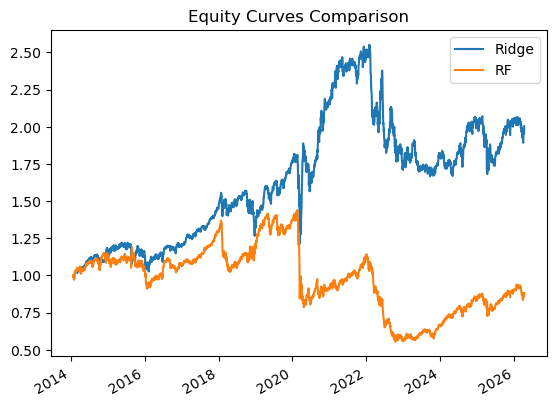

In [43]:
(1+ridge_strat).cumprod().plot(label='Ridge')
(1+rf_strat).cumprod().plot(label='RF')
plt.legend()
plt.title('Equity Curves Comparison')
plt.savefig(plots_dir / "equity_comparison.png")
plt.show()

## Rolling Sharpe Ratio

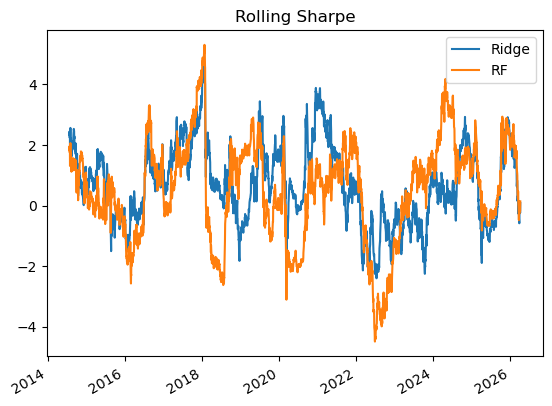

In [44]:
def rolling_sharpe(r, window=126):
    return np.sqrt(252) * r.rolling(window).mean() / r.rolling(window).std()

rolling_sharpe(ridge_strat).plot(label='Ridge')
rolling_sharpe(rf_strat).plot(label='RF')
plt.legend(); plt.title('Rolling Sharpe'); 
plt.savefig(plots_dir / "rolling_sharpe.png")
plt.show()

## Feature Importance (Random Forest)

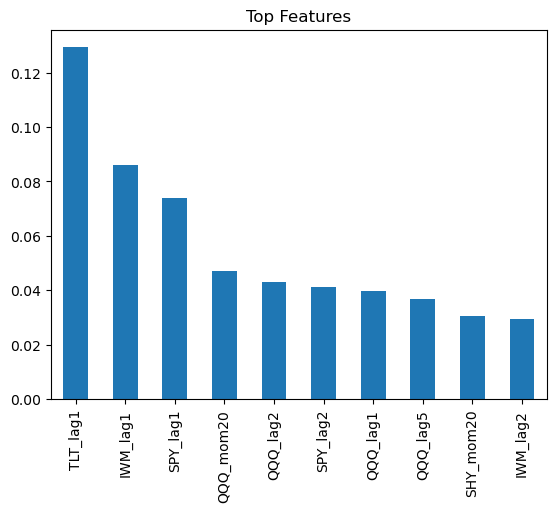

In [45]:
model = train_model(X.iloc[:1000], y.iloc[:1000], 'rf')
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top Features')
plt.savefig(plots_dir / "feature_importance_rf.png")
plt.show()

## Summary

### Metrics

In [49]:
def sharpe(r):
    return (r.mean() / r.std()) * (252**0.5)

metrics = pd.DataFrame({
    "model": ["ridge", "rf"],
    "sharpe": [sharpe(ridge_strat), sharpe(rf_strat)],
    "mean_return": [ridge_strat.mean(), rf_strat.mean()],
    "volatility": [ridge_strat.std(), rf_strat.std()]
})

metrics.to_csv(results_dir /"metrics.csv", index=False)
metrics

,model,sharpe,mean_return,volatility
0,ridge,0.416269,0.000286,0.010911
1,rf,0.027881,0.000019,0.010915


### Returns

In [50]:
returns_df = pd.DataFrame({
    "ridge": ridge_strat,
    "rf": rf_strat
})
returns_df.to_csv(results_dir /"returns.csv")
returns_df

,ridge,rf
2014-01-23,NaN,NaN
2014-01-24,NaN,NaN
2014-01-27,-0.004928,-0.004928
2014-01-28,0.005949,0.005949
2014-01-29,-0.009612,-0.009612
...,...,...
2026-04-01,0.007524,-0.007553
2026-04-02,0.000897,-0.000904
2026-04-06,-0.004730,-0.004729
2026-04-07,-0.000442,0.000437


### Predictions

In [51]:
preds_df = pd.DataFrame({
    "ridge": ridge_preds,
    "rf": rf_preds
})
preds_df.to_csv(results_dir /"predictions.csv")
preds_df

,ridge,rf
2014-01-23,0.000140,0.000723
2014-01-24,0.000672,0.000723
2014-01-27,0.000923,0.000536
2014-01-28,0.000938,0.000635
2014-01-29,0.000952,0.000554
...,...,...
2026-04-01,0.000113,-0.000022
2026-04-02,-0.000054,-0.001821
2026-04-06,-0.000198,0.000341
2026-04-07,0.000339,0.000052
